# Introduction to CLV Models

**The question**

I have a list of customers and a pile of past orders. Two things I'd like to know:

- Which of these customers are still my customers? Nobody cancels a retail account — they just stop coming back. A customer who bought five times and last showed up yesterday and one who bought five times and vanished in March look identical in a `GROUP BY`.
- What is each one worth from here on?

This is the **non-contractual** setting, and it is what `optistock.clv` is for. Two models split the work:

| Question | Model |
|---|---|
| How often will they buy, and are they still active? | `ParetoNBD` |
| How much do they spend per purchase? | `GammaGammaSpend` |

Multiply the two and you get expected lifetime value.

**The plan for this notebook**

1. Simulate order lines from a **known** generative process, so we can check the models recover the truth.
2. Summarise them into RFM with `rfm_summary`.
3. Fit `ParetoNBD` — recover the parameters, ask who is still alive.
4. Fit `GammaGammaSpend` — see what shrinkage buys us.
5. Combine into a CLV leaderboard.
6. Validate on a **holdout window** — the honest test.
7. Add a covariate, and tweak priors.

Everything is fitted with **`method="demz"`** (DEMetropolisZ). On these four-parameter models it lands in the same place as NUTS and is roughly an order of magnitude faster, which makes it the right default while iterating. `method="map"` is faster still but returns a single point with no posterior spread, and `method="mcmc"` is the one to re-run before you trust the numbers in anger.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from optistock.clv import (
    GammaGammaSpend,
    ParetoNBD,
    ParetoNBDPriors,
    rfm_summary,
    rfm_train_test_split,
)
from optistock.forecasting import Prior

rng = np.random.default_rng(42)

# Shared sampler settings — DEMetropolisZ, see the note above.
FIT = dict(method="demz", draws=1500, tune=1500, chains=4, progressbar=False)

## 1. Synthetic data from a known process

The Pareto/NBD story, generated literally:

- Each customer draws a **purchase rate** $\lambda_i \sim \mathrm{Gamma}(r, \alpha)$ and a **dropout rate** $\mu_i \sim \mathrm{Gamma}(s, \beta)$.
- They stay active for a lifetime $\tau_i \sim \mathrm{Exponential}(\mu_i)$, buying as a Poisson process, then silently stop.
- We watch the store over a fixed calendar window. Customers arrive at different times, so each has their own observation length $T_i$.
- Crucially, **we never see $\tau_i$** — a customer who has gone quiet might have left or might just be slow. Untangling those two is the model's whole job.

Spend follows the Gamma-Gamma story: each customer has their own scale $\nu_i \sim \mathrm{Gamma}(q, v)$, and every basket is $\mathrm{Gamma}(p, \nu_i)$.

Writing it as a function, because section 7 needs a second dataset.

In [2]:
# --- true parameters, recovered later ---
TRUE_R, TRUE_ALPHA = 0.9, 12.0            # purchase rate:  Gamma(r, alpha)
TRUE_S, TRUE_BETA = 0.9, 25.0             # dropout rate:   Gamma(s, beta)
TRUE_P, TRUE_Q, TRUE_V = 6.0, 4.0, 22.5   # spend: Gamma(p, nu), nu ~ Gamma(q, v)

N_CUSTOMERS = 1500
WINDOW = 270                              # days of calendar history
START = pd.Timestamp("2023-01-01")


def simulate_orders(n=N_CUSTOMERS, tier_uplift=1.0, seed=42):
    """
    Generate order lines from the Pareto/NBD + Gamma-Gamma process.

    `tier_uplift` is how much more often tier-1 customers buy. Left at 1.0 the
    `tier` column is recorded but inert — section 7 turns it on.

    Returns the order lines plus the *hidden* truth (lifetimes, observation
    windows) that the models never get to see.
    """
    rng = np.random.default_rng(seed)
    tier = rng.integers(0, 2, n)

    # Purchase rate: a smaller alpha means a higher lambda, so tier-1 buys more.
    alpha_i = np.where(tier == 1, TRUE_ALPHA / tier_uplift, TRUE_ALPHA)
    lam = rng.gamma(TRUE_R, 1 / alpha_i)

    # Dropout rate, and the unobserved lifetime it implies.
    mu = rng.gamma(TRUE_S, 1 / TRUE_BETA, size=n)
    tau = rng.exponential(1 / mu)

    # Customers are acquired at different times; T is what is left of the window.
    acquired = rng.integers(0, 120, n)
    T = WINDOW - acquired
    active = np.minimum(tau, T)           # buying stops at dropout or window end

    nu = rng.gamma(TRUE_Q, 1 / TRUE_V, size=n)   # per-customer spend scale

    rows = []
    for i in range(n):
        n_repeat = rng.poisson(lam[i] * active[i])
        # Given the count, Poisson event times are uniform on the active window.
        offsets = np.concatenate([[0.0], np.sort(rng.uniform(0, active[i], n_repeat))])
        for offset in offsets:
            rows.append(
                {
                    "customer_id": f"C{i:04d}",
                    "date": START + pd.Timedelta(days=int(acquired[i] + offset)),
                    "revenue": float(rng.gamma(TRUE_P, 1 / nu[i])),
                    "tier": float(tier[i]),
                }
            )

    orders = pd.DataFrame(rows).sort_values(["customer_id", "date"]).reset_index(drop=True)
    hidden = pd.DataFrame(
        {"customer_id": [f"C{i:04d}" for i in range(n)], "alive_at_end": tau >= T}
    ).set_index("customer_id")
    return orders, hidden


orders, hidden = simulate_orders()

print(f"{len(orders):,} order lines from {orders.customer_id.nunique():,} customers")
print(f"{orders.date.min().date()} to {orders.date.max().date()}")
print(f"{1 - hidden.alive_at_end.mean():.0%} of customers have truly churned by the window end")
orders.head()

8,707 order lines from 1,500 customers
2023-01-01 to 2023-09-27
87% of customers have truly churned by the window end


,customer_id,date,revenue,tier
0,C0000,2023-03-30,40.599640,0.0
1,C0000,2023-06-04,41.297982,0.0
2,C0001,2023-01-16,23.255967,1.0
3,C0002,2023-02-18,60.845929,1.0
4,C0002,2023-03-28,61.930784,1.0


### What churn looks like from the outside

Each row is a customer, each dot a purchase. Rows are coloured by whether that customer is *actually* still active at the end of the window — the fact we are trying to infer, and the one you never have in real data.

Cover the colours and the two groups are genuinely hard to tell apart. That is the problem.

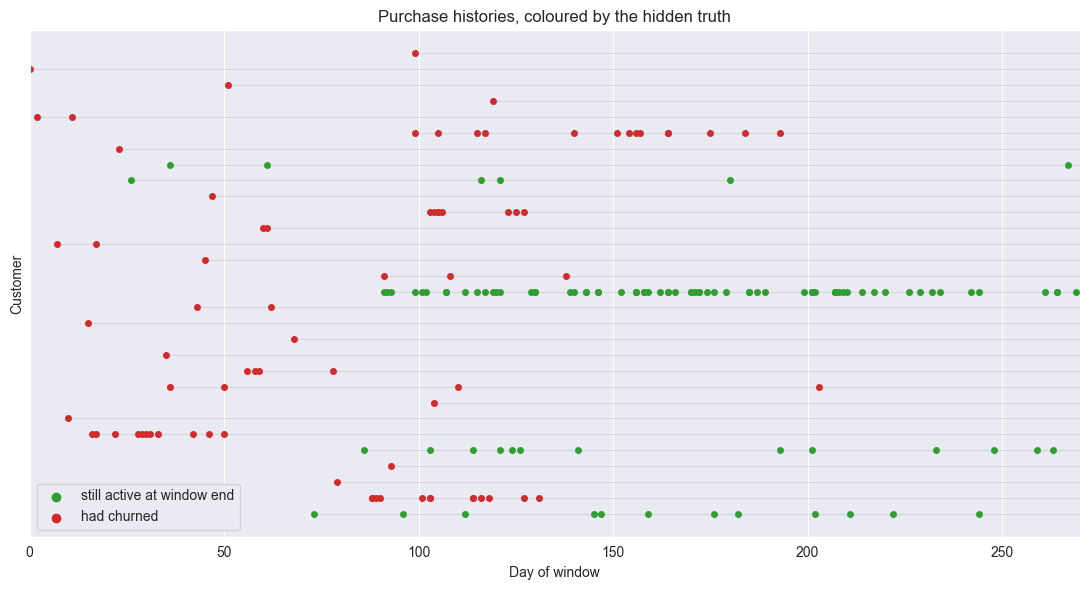

In [3]:
show = rng.choice(N_CUSTOMERS, 30, replace=False)

fig, ax = plt.subplots(figsize=(11, 6))
for row, i in enumerate(show):
    cid = f"C{i:04d}"
    days = (orders.loc[orders.customer_id == cid, "date"] - START).dt.days
    alive = hidden.loc[cid, "alive_at_end"]
    color = "C2" if alive else "C3"
    ax.hlines(row, days.min(), WINDOW, color="grey", lw=0.4, alpha=0.4)
    ax.scatter(days, np.full(len(days), row), s=16, color=color)

ax.scatter([], [], color="C2", label="still active at window end")
ax.scatter([], [], color="C3", label="had churned")
ax.set_xlabel("Day of window")
ax.set_ylabel("Customer")
ax.set_yticks([])
ax.set_title("Purchase histories, coloured by the hidden truth")
ax.set_xlim(0, WINDOW)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 2. Order lines to RFM

Both models want one row per customer. `rfm_summary` does the aggregation — it is `pymc-marketing`'s, re-exported from `optistock.clv` so you don't need a second import.

- `frequency` — **repeat** purchases (the first one doesn't count; it carries no information about repeat behaviour)
- `recency` — when the last purchase happened, measured from acquisition
- `T` — how long we have been watching
- `monetary_value` — **mean** spend per transaction, not the total

In [4]:
rfm = rfm_summary(
    orders,
    customer_id_col="customer_id",
    datetime_col="date",
    monetary_value_col="revenue",
)

# Carry the tier attribute across for section 7.
rfm = rfm.merge(
    orders.groupby("customer_id")["tier"].first().rename("tier"),
    on="customer_id",
)

print(f"{(rfm.frequency == 0).mean():.0%} of customers never came back")
rfm.describe().round(2)

41% of customers never came back


,frequency,recency,T,monetary_value,tier
count,1500.00,1500.0,1500.00,1500.00,1500.00
mean,4.40,43.8,210.58,29.40,0.51
std,8.42,66.3,35.03,38.82,0.50
min,0.00,0.0,150.00,0.00,0.00
25%,0.00,0.0,180.00,0.00,0.00
50%,1.00,8.0,211.00,20.95,1.00
75%,5.00,63.0,242.00,42.76,1.00
max,65.00,263.0,269.00,405.93,1.00


## 3. `ParetoNBD` — how often, and are they still alive?

Priors first. Every model in the repo carries a typed `*Priors` dataclass, and `describe_priors()` prints what is actually in the model — no digging through source.

In [5]:
txn = ParetoNBD(rfm)
_ = txn.describe_priors()

ParetoNBDPriors:
Variable              Distribution  Parameters        Description
-----------------------------------------------------------------
r                     Weibull       alpha=2, beta=1   Population shape of the customer purchase rate
alpha                 Weibull       alpha=2, beta=10  Population scale of the customer purchase rate
s                     Weibull       alpha=2, beta=1   Population shape of the customer dropout rate
beta                  Weibull       alpha=2, beta=10  Population scale of the customer dropout rate
purchase_coefficient  Normal        mu=0, sigma=1     Covariate effect on the purchase rate (only used with covariates)
dropout_coefficient   Normal        mu=0, sigma=1     Covariate effect on the dropout rate (only used with covariates)


In [6]:
%time txn.fit(**FIT)
txn.summary().round(3)

Multiprocess sampling (4 chains in 4 jobs)


DEMetropolisZ: [alpha, beta, r, s]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 24 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: total: 3.42 s
Wall time: 25.8 s


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,14.865,1.220,12.619,17.189,0.055,0.030,478.0,691.0,1.01
beta,20.823,3.066,15.435,26.748,0.185,0.096,260.0,260.0,1.02
r,1.028,0.086,0.877,1.196,0.004,0.002,511.0,865.0,1.00
s,0.823,0.064,0.709,0.946,0.004,0.002,278.0,437.0,1.01


Note the `r_hat` warning and the modest `ess_bulk`. That is the DEMetropolisZ trade-off showing up honestly: it explores far more cheaply than NUTS but mixes less efficiently, so the diagnostics are looser. Fine for the parameter estimates we are about to look at; re-run with `method="mcmc"` before publishing a number.

### Did it find the truth?

The four parameters are the population Gammas we simulated from.

In [7]:
truth = {"r": TRUE_R, "alpha": TRUE_ALPHA, "s": TRUE_S, "beta": TRUE_BETA}
post = txn.idata.posterior

recovery = pd.DataFrame(
    {
        "true": truth,
        "posterior mean": {k: float(post[k].mean()) for k in truth},
        "3%": {k: float(post[k].quantile(0.03)) for k in truth},
        "97%": {k: float(post[k].quantile(0.97)) for k in truth},
    }
).round(2)
recovery["recovered"] = (recovery["3%"] <= recovery["true"]) & (
    recovery["true"] <= recovery["97%"]
)
recovery

,true,posterior mean,3%,97%,recovered
r,0.9,1.03,0.88,1.19,True
alpha,12.0,14.87,12.63,17.29,False
s,0.9,0.82,0.71,0.95,True
beta,25.0,20.82,15.65,27.03,True


Three of the four intervals cover the truth, and `alpha` sits a little high.

That is the expected picture, because a shape and a scale that grow together describe a similar distribution: `r` trades off against `alpha`, and `s` against `beta`. What each pair pins down well is the **rate** it implies — which is what actually drives every prediction:

In [8]:
for name, shape, scale in [("purchase", "r", "alpha"), ("dropout", "s", "beta")]:
    est = float((post[shape] / post[scale]).mean())
    true = truth[shape] / truth[scale]
    print(f"mean {name:>8} rate — true {true:.4f}, estimated {est:.4f}  "
          f"({est / true - 1:+.0%})")

print(f"\nimplied mean customer lifetime — true {TRUE_BETA / TRUE_S:.0f} days, "
      f"estimated {float((post['beta'] / post['s']).mean()):.0f} days")

mean purchase rate — true 0.0750, estimated 0.0692  (-8%)
mean  dropout rate — true 0.0360, estimated 0.0400  (+11%)

implied mean customer lifetime — true 28 days, estimated 25 days


### Who is still alive?

Here is the question a `GROUP BY` cannot answer. Two customers, identical purchase counts, different recency:

In [9]:
twins = pd.DataFrame(
    {
        "customer_id": ["bought recently", "went quiet"],
        "frequency": [8.0, 8.0],
        "recency": [230.0, 60.0],
        "T": [250.0, 250.0],
    }
)

alive = txn.expected_probability_alive(data=twins).mean(("chain", "draw"))
purchases = txn.expected_purchases(data=twins, future_t=90).mean(("chain", "draw"))

pd.DataFrame(
    {
        "P(alive)": alive.to_series().round(3),
        "expected purchases, next 90d": purchases.to_series().round(2),
    }
)

,P(alive),"expected purchases, next 90d"
customer_id,,
bought recently,0.913,2.48
went quiet,0.000,0.00


Same history length, same number of purchases — very different conclusions. That gap is the entire value of the model.

Across the whole customer base:

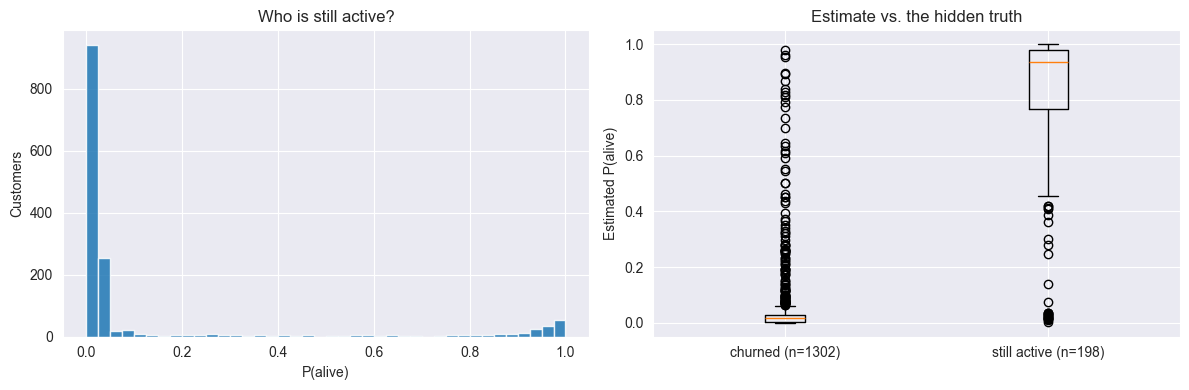

In [10]:
p_alive = txn.expected_probability_alive().mean(("chain", "draw")).to_series()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(p_alive, bins=40, color="C0", alpha=0.85)
axes[0].set_xlabel("P(alive)")
axes[0].set_ylabel("Customers")
axes[0].set_title("Who is still active?")

# The model never sees the true lifetimes, so this is a genuine check.
truly_alive = hidden.alive_at_end.reindex(p_alive.index)
axes[1].boxplot(
    [p_alive[~truly_alive], p_alive[truly_alive]],
    tick_labels=[f"churned (n={(~truly_alive).sum()})",
                 f"still active (n={truly_alive.sum()})"],
)
axes[1].set_ylabel("Estimated P(alive)")
axes[1].set_title("Estimate vs. the hidden truth")

plt.tight_layout()
plt.show()

### The frequency / recency planes

Two diagnostic heatmaps, wrapped from `pymc-marketing` to return `(fig, ax)` like everything else in the repo. They sweep a synthetic grid of customers, so they show the model's *shape* rather than your actual customers.

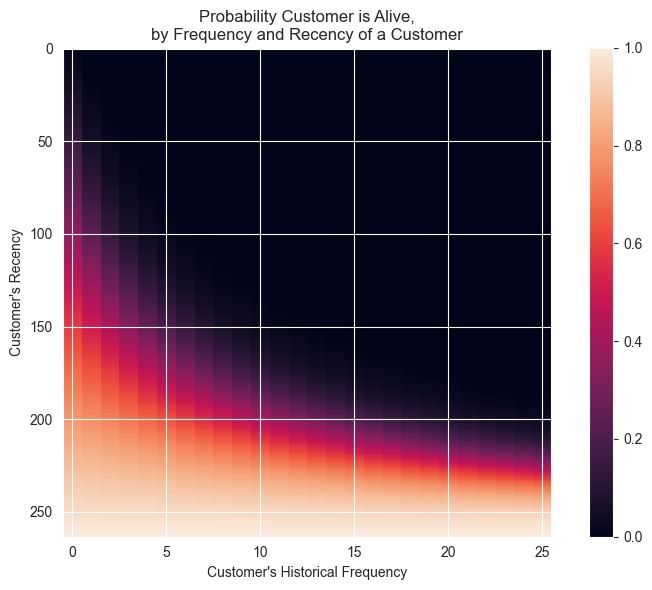

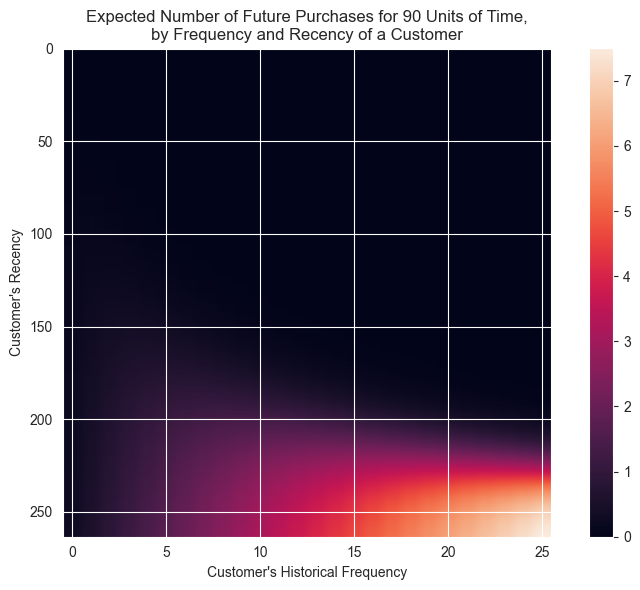

In [11]:
fig, _ = txn.plot_probability_alive_matrix(max_frequency=25)
plt.show()

fig, _ = txn.plot_frequency_recency_matrix(future_t=90, max_frequency=25)
plt.show()

Read the first one along a row: at a fixed purchase count, P(alive) collapses as recency drops. And note the top-left corner — a customer who bought *many* times but has gone quiet is judged more harshly than an infrequent one who did the same, because for a heavy buyer, silence is far more surprising.

## 4. `GammaGammaSpend` — how much per purchase

Fitted on **repeat buyers only**: a customer with a single purchase tells you nothing about how their spend varies, so `frequency == 0` rows are rejected outright rather than silently dropped.

In [12]:
repeat = rfm[rfm.frequency > 0]
print(f"fitting on {len(repeat):,} repeat buyers of {len(rfm):,}")

spend = GammaGammaSpend(repeat)
%time spend.fit(**FIT)

sp = spend.idata.posterior
pd.DataFrame(
    {
        "true": {"p": TRUE_P, "q": TRUE_Q, "v": TRUE_V},
        "posterior mean": {k: float(sp[k].mean()) for k in ("p", "q", "v")},
    }
).round(2)

fitting on 888 repeat buyers of 1,500


Multiprocess sampling (4 chains in 4 jobs)


DEMetropolisZ: [p, q, v]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 16 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: total: 1.17 s
Wall time: 16.7 s


,true,posterior mean
p,6.0,975.18
q,4.0,3.69
v,22.5,28.60


Those three don't land as neatly as the Pareto/NBD parameters did, and they aren't supposed to: `p`, `q` and `v` are only weakly identified *individually* — with `HalfFlat` priors, different combinations describe nearly the same spend distribution, and re-running with another seed moves them around.

What is pinned down is the quantity they combine into, the population mean spend $pv/(q-1)$:

In [13]:
implied = float((sp["p"] * sp["v"] / (sp["q"] - 1)).mean())

print(f"model implied population mean spend : {implied:.2f}")
print(f"expected_new_customer_spend()       : {float(spend.expected_new_customer_spend().mean()):.2f}")
print(f"observed mean of customer means     : {repeat.monetary_value.mean():.2f}")

model implied population mean spend : 50.01
expected_new_customer_spend()       : 50.01
observed mean of customer means     : 49.66


### What shrinkage buys you

The naive estimate of a customer's spend is their observed average. For someone with one purchase that average is noise. The model pulls each customer towards the population mean by an amount that depends on how much evidence they have — hard for a one-off buyer, barely at all for a regular.

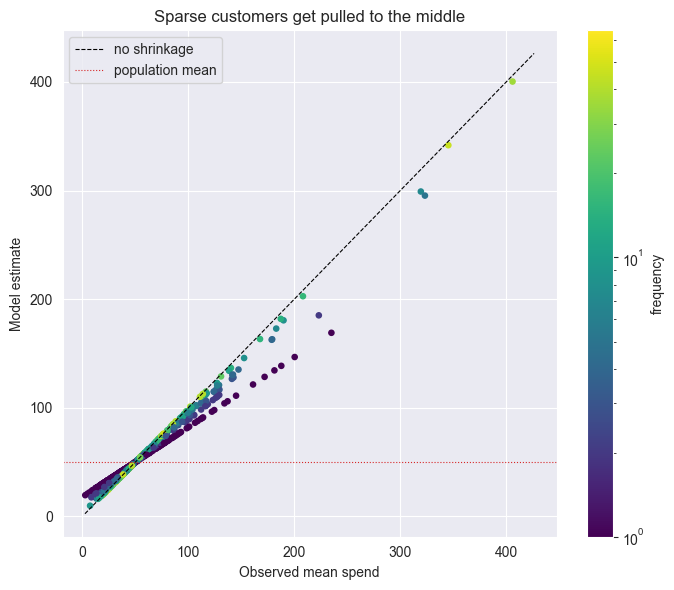

In [14]:
predicted = spend.expected_customer_spend().mean(("chain", "draw")).to_series()
observed = repeat.set_index("customer_id")["monetary_value"].reindex(predicted.index)
freq = repeat.set_index("customer_id")["frequency"].reindex(predicted.index)

fig, ax = plt.subplots(figsize=(7, 6))
pts = ax.scatter(observed, predicted, c=freq, cmap="viridis", s=14, norm="log")
lims = [observed.min() * 0.9, observed.max() * 1.05]
ax.plot(lims, lims, "k--", lw=0.8, label="no shrinkage")
ax.axhline(observed.mean(), color="C3", lw=0.8, ls=":", label="population mean")
ax.set_xlabel("Observed mean spend")
ax.set_ylabel("Model estimate")
ax.set_title("Sparse customers get pulled to the middle")
ax.legend()
plt.colorbar(pts, label="frequency")
plt.tight_layout()
plt.show()

The dark points — one or two purchases — sit well off the diagonal, hauled towards the red line. The bright ones sit almost on it: the model trusts a customer with thirty baskets.

One assumption worth checking before you rely on this: Gamma-Gamma requires **spend and frequency to be independent**. If heavy buyers systematically fill smaller baskets, it breaks.

Check it on the frame you actually fit — repeat buyers. Including the one-and-done customers manufactures a correlation out of nothing, because every one of them has a `monetary_value` of 0:

In [15]:
print(f"all customers : {rfm[['frequency', 'monetary_value']].corr().iloc[0, 1]:+.3f}"
      "   <- artefact: frequency-0 customers all have monetary_value 0")
print(f"repeat buyers : {repeat[['frequency', 'monetary_value']].corr().iloc[0, 1]:+.3f}"
      "   <- the one that matters (want ~0)")

all customers : +0.315   <- artefact: frequency-0 customers all have monetary_value 0
repeat buyers : +0.060   <- the one that matters (want ~0)


## 5. Putting them together — CLV

`expected_customer_lifetime_value` takes the fitted transaction model, projects purchases forward, values each at the customer's expected spend, and discounts back.

> ⚠️ **`future_t` is in months here — and only here.**
>
> | Method | Unit of `future_t` |
> |---|---|
> | `ParetoNBD.expected_purchases` | your data's time unit (days, for us) |
> | `expected_customer_lifetime_value` | **always months**, whatever `time_unit` says |
>
> An inconsistency inherited from `pymc-marketing`, and from `lifetimes` before it. On daily data `future_t=90` means 90 *months*, so a "quarter" is `future_t=3`. `discount_rate` is per month to match. Easy to get wrong — the giveaway is a leaderboard with implausibly large numbers on it.

In [16]:
clv = spend.expected_customer_lifetime_value(
    txn,
    future_t=3,            # MONTHS — one quarter
    discount_rate=0.01,    # per month
)

leaderboard = (
    clv.mean(("chain", "draw"))
    .to_dataframe("clv")
    .join(repeat.set_index("customer_id")[["frequency", "recency", "monetary_value"]])
    .sort_values("clv", ascending=False)
)
leaderboard.head(10).round(2)

,clv,frequency,recency,monetary_value
customer_id,,,,
C0988,4965.72,46.0,224.0,345.36
C0678,1702.74,41.0,168.0,101.85
C1289,1698.58,41.0,196.0,113.70
C0790,1390.02,40.0,170.0,88.10
C0492,1355.68,16.0,163.0,208.16
C1388,1316.05,40.0,254.0,110.99
C0433,1118.95,23.0,155.0,116.58
C1311,1099.08,50.0,263.0,76.46
C1200,1010.80,39.0,246.0,85.47


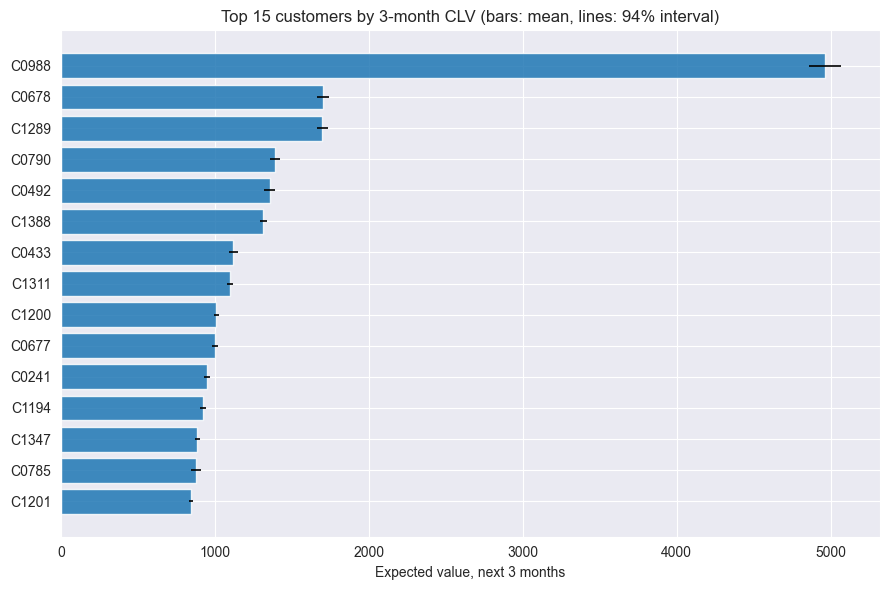

In [17]:
top = leaderboard.head(15).iloc[::-1]
lo = clv.quantile(0.03, dim=("chain", "draw")).to_series().reindex(top.index)
hi = clv.quantile(0.97, dim=("chain", "draw")).to_series().reindex(top.index)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.clv, color="C0", alpha=0.85)
ax.hlines(top.index, lo, hi, color="k", lw=1.2)
ax.set_xlabel("Expected value, next 3 months")
ax.set_title("Top 15 customers by 3-month CLV (bars: mean, lines: 94% interval)")
plt.tight_layout()
plt.show()

The intervals matter. The ranking is a posterior, not a fact — several of these customers overlap enough that their order could swap. If you are picking a retention list, the top of this chart is a reasonable target; arguing about rank 8 versus rank 11 is not.

## 6. The honest test — a holdout window

Parameter recovery on data you simulated is a sanity check, not a validation. The real question is whether the model predicts purchases it never saw.

`rfm_train_test_split` cuts the history at a date: the model learns from everything before it, and we score it on the days after.

In [18]:
cutoff = START + pd.Timedelta(days=200)

split = rfm_train_test_split(
    orders,
    customer_id_col="customer_id",
    datetime_col="date",
    train_period_end=cutoff,
    monetary_value_col="revenue",
)

holdout_model = ParetoNBD(split[["customer_id", "frequency", "recency", "T"]])
%time holdout_model.fit(**FIT)

test_days = float(split.test_T.iloc[0])
split["predicted"] = split.customer_id.map(
    holdout_model.expected_purchases(future_t=test_days).mean(("chain", "draw")).to_series()
)
print(f"scoring on {test_days:.0f} unseen days")

Multiprocess sampling (4 chains in 4 jobs)


DEMetropolisZ: [alpha, beta, r, s]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 22 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: total: 1.72 s
Wall time: 22.4 s


scoring on 69 unseen days


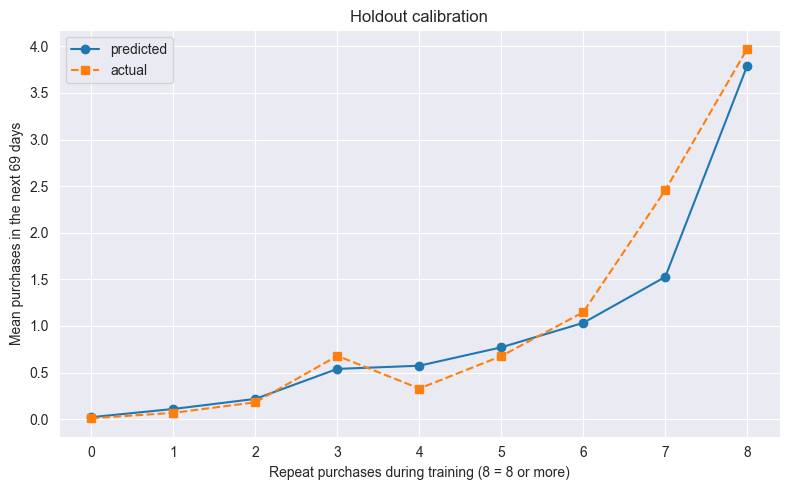

,n,predicted,actual
bucket,,,
0.0,617,0.02,0.01
1.0,236,0.11,0.07
2.0,138,0.22,0.18
3.0,78,0.54,0.68
4.0,73,0.57,0.33
5.0,65,0.77,0.68
6.0,27,1.03,1.15
7.0,35,1.53,2.46
8.0,231,3.79,3.97


In [19]:
# Group customers by how many purchases they made in the training window: does the
# model get the *average* right within each group?
calib = (
    split.assign(bucket=split.frequency.clip(upper=8))
    .groupby("bucket")[["predicted", "test_frequency"]]
    .agg(["mean", "size"])
)
calib.columns = ["predicted", "n", "actual", "_"]
calib = calib[["n", "predicted", "actual"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(calib.index, calib.predicted, "o-", label="predicted")
ax.plot(calib.index, calib.actual, "s--", label="actual")
ax.set_xlabel("Repeat purchases during training (8 = 8 or more)")
ax.set_ylabel(f"Mean purchases in the next {test_days:.0f} days")
ax.set_title("Holdout calibration")
ax.legend()
plt.tight_layout()
plt.show()

calib.round(2)

In [20]:
err = split.predicted - split.test_frequency
print(f"MAE  {err.abs().mean():.3f} purchases per customer")
print(f"bias {err.mean():+.3f}  (positive = over-predicting)")
print(f"total predicted {split.predicted.sum():,.0f} vs actual {split.test_frequency.sum():,.0f}")

MAE  0.515 purchases per customer
bias -0.029  (positive = over-predicting)
total predicted 1,160 vs actual 1,203


Tracking the actual line across the frequency range, with aggregate error well under one purchase per customer, is what "this model works" looks like. If the predicted line drifted above the actual at high frequencies, the model would be failing to notice churn among your best customers — the expensive failure mode.

## 7. Covariates

This is why `ParetoNBD` is the transaction model here rather than BG/NBD: it accepts customer attributes that shift the purchase or dropout rate.

The `tier` column has been inert so far. Here is a fresh dataset where it genuinely matters — tier-1 customers buy **1.8× more often**:

In [21]:
TIER_UPLIFT = 1.8

orders_tier, _ = simulate_orders(tier_uplift=TIER_UPLIFT, seed=11)
rfm_tier = rfm_summary(
    orders_tier, "customer_id", "date", monetary_value_col="revenue"
).merge(orders_tier.groupby("customer_id")["tier"].first(), on="customer_id")

by_tier = rfm_tier.groupby("tier").frequency.mean()
print(f"observed mean frequency — tier 0: {by_tier[0]:.2f}, tier 1: {by_tier[1]:.2f}")

observed mean frequency — tier 0: 4.62, tier 1: 6.98


In [22]:
txn_cov = ParetoNBD(rfm_tier, purchase_covariate_cols=["tier"])
%time txn_cov.fit(**FIT)

coef = txn_cov.idata.posterior["purchase_coefficient"]
print(f"purchase_coefficient: {float(coef.mean()):+.3f} "
      f"[{float(coef.quantile(0.03)):+.3f}, {float(coef.quantile(0.97)):+.3f}]")

Multiprocess sampling (4 chains in 4 jobs)


DEMetropolisZ: [purchase_coefficient, alpha_scale, beta, r, s]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 23 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: total: 3.3 s
Wall time: 23.8 s
purchase_coefficient: +0.501 [+0.385, +0.603]


The interval is nowhere near zero, so the model has found the effect. But the raw coefficient is a poor thing to interpret directly — it acts on `pymc-marketing`'s internal parameterisation of the rate. Read it through a prediction instead.

The natural place to look is a **brand-new customer**, where there is no purchase history and the covariate is all the model has to go on:

In [23]:
new = pd.DataFrame(
    {
        "customer_id": ["tier 0", "tier 1"],
        "frequency": [0.0, 0.0],
        "recency": [0.0, 0.0],
        "T": [0.0, 0.0],
        "tier": [0.0, 1.0],
    }
)

pred = (
    txn_cov.expected_purchases_new_customer(data=new, t=90)
    .mean(("chain", "draw"))
    .to_series()
)
print(pred.round(2).to_string())
print(f"\ntier-1 uplift: {pred['tier 1'] / pred['tier 0']:.2f}x  (simulated: {TIER_UPLIFT}x)")

customer_id
tier 0    2.80
tier 1    4.62

tier-1 uplift: 1.65x  (simulated: 1.8x)


### Where covariates do and don't move the needle

Now the same comparison for **existing** customers, holding the history identical and varying only the tier:

In [24]:
rows = []
for freq in [0.0, 1.0, 3.0, 8.0]:
    twins = pd.DataFrame(
        {
            "customer_id": ["tier 0", "tier 1"],
            "frequency": [freq, freq],
            "recency": [200.0, 200.0],
            "T": [250.0, 250.0],
            "tier": [0.0, 1.0],
        }
    )
    p = txn_cov.expected_purchases(data=twins, future_t=90).mean(("chain", "draw")).to_series()
    rows.append({"frequency": freq, "tier 0": p["tier 0"], "tier 1": p["tier 1"],
                 "ratio": p["tier 1"] / p["tier 0"]})

pd.DataFrame(rows).set_index("frequency").round(3)

,tier 0,tier 1,ratio
frequency,,,
0.0,0.297,0.304,1.025
1.0,0.528,0.541,1.025
3.0,0.954,0.975,1.022
8.0,1.713,1.733,1.012


Barely any difference — around 2%, against the 66% uplift the same model gives for a brand-new customer. That is correct behaviour, not a bug, and it is the most useful thing in this section.

The covariate shifts the **prior** on a customer's purchase rate. The moment you condition on an actual history, that history does the talking. Note this holds even in the `frequency = 0` row: "bought nothing in 250 days" is not missing information, it is *strong* information, and it swamps whatever the tier suggested.

The practical reading: covariates earn their keep at **cold start**, on customers you have not watched yet — exactly where plain RFM has nothing to say. Do not expect them to re-rank your existing customer base.

One limitation to know about: the two matrix heatmaps are **not available** on a covariate model. They sweep a grid of invented customers, and there is no principled covariate value to give them. You get a clear error rather than a confusing one from deep inside the library:

In [25]:
try:
    txn_cov.plot_probability_alive_matrix()
except NotImplementedError as e:
    print(e)

plot_probability_alive_matrix() is not available on a model fitted with covariates: the plot sweeps a synthetic frequency/recency grid, which has no covariate values to condition on. Predict on real customers with expected_probability_alive()/expected_purchases() instead, or fit a second model without covariates for the diagnostic view.


## 8. Changing the priors

Same pattern as every other model in the repo: build a `*Priors` dataclass, override the fields you care about, pass it in. The defaults reproduce `pymc-marketing`'s own, so leaving `priors=` off changes nothing.

In [26]:
tight = ParetoNBDPriors(
    alpha=Prior("Weibull", {"alpha": 3, "beta": 7}, "Purchase-rate scale — tightened"),
    r=Prior("Gamma", {"alpha": 2, "beta": 2}, "Purchase-rate shape — swapped to Gamma"),
)

txn_tight = ParetoNBD(rfm, priors=tight)
_ = txn_tight.describe_priors()

ParetoNBDPriors:
Variable              Distribution  Parameters        Description
-----------------------------------------------------------------
r                     Gamma         alpha=2, beta=2   Purchase-rate shape — swapped to Gamma
alpha                 Weibull       alpha=3, beta=7   Purchase-rate scale — tightened
s                     Weibull       alpha=2, beta=1   Population shape of the customer dropout rate
beta                  Weibull       alpha=2, beta=10  Population scale of the customer dropout rate
purchase_coefficient  Normal        mu=0, sigma=1     Covariate effect on the purchase rate (only used with covariates)
dropout_coefficient   Normal        mu=0, sigma=1     Covariate effect on the dropout rate (only used with covariates)


In [27]:
%time txn_tight.fit(**FIT)

pd.DataFrame(
    {
        "true": truth,
        "default priors": {k: float(txn.idata.posterior[k].mean()) for k in truth},
        "tightened priors": {k: float(txn_tight.idata.posterior[k].mean()) for k in truth},
    }
).round(2)

Multiprocess sampling (4 chains in 4 jobs)


DEMetropolisZ: [alpha, beta, r, s]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 22 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


CPU times: total: 1.78 s
Wall time: 22.2 s


,true,default priors,tightened priors
r,0.9,1.03,0.93
alpha,12.0,14.87,13.34
s,0.9,0.82,0.83
beta,25.0,20.82,21.90


With 1,500 customers the likelihood does most of the work: swapping a distribution and tightening a scale nudges the estimates rather than moving them somewhere new. (If anything the tightened version lands slightly closer to the truth on `r` and `alpha` — a reasonable prior helping a weakly identified pair.)

Priors earn their keep on small or sparse customer bases, where the data cannot pin the population parameters down on its own.

## Summary

| Step | Code |
|---|---|
| Order lines to RFM | `rfm_summary(orders, "customer_id", "date", monetary_value_col="revenue")` |
| Purchase frequency | `ParetoNBD(rfm).fit(method="demz")` |
| Still active? | `.expected_probability_alive()` |
| Future purchases | `.expected_purchases(future_t=90)` |
| Spend per basket | `GammaGammaSpend(rfm[rfm.frequency > 0]).fit(method="demz")` |
| Lifetime value | `spend.expected_customer_lifetime_value(txn, future_t=3)` — **months** |
| Validation | `rfm_train_test_split(...)`, then score against `test_frequency` |

**Things worth carrying forward**

- Recency, not purchase count, drives P(alive) — that is the whole point of the model, and the thing a spreadsheet won't give you.
- Fit with `demz` while iterating, `map` for a throwaway point estimate, and confirm with `mcmc` before you act on the numbers. (`map` needs `pymc-marketing>=0.19.4`.)
- Judge these models on the **rates and predictions** they imply, not on individual shape/scale parameters — those are weakly identified and trade off against each other in both models.
- Gamma-Gamma goes on repeat buyers only, and assumes spend is independent of frequency. Check that correlation on the repeat buyers, not the full base.
- Covariates move **cold-start** predictions. Once a customer has a history, that history dominates — don't expect a covariate to re-rank people you have already watched.
- `future_t` is **months** in `expected_customer_lifetime_value`, but your data's time unit in `expected_purchases`. Mixing them up silently inflates every number.
- CLV is a posterior. Use the intervals; don't over-read the ranking.
- Anything not wrapped is reachable via `model.model`, the underlying `pymc-marketing` object.

Further reading: [docs/clv.md](../docs/clv.md) for the API, [docs/priors.md](../docs/priors.md) for the prior system.